In [1]:
import pandas as pd
import numpy as np
from combat.pycombat import pycombat  # pip install combat
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import *
from sklearn.cluster import AgglomerativeClustering
import umap
import seaborn as sns  # For h-clust mostly
import plotly.express as px
import plotly.graph_objects as go  # For heatmaps

/home/felix/.local/share/mamba/envs/NSBEpi/lib/python3.9/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# To make plotly fig show in notebook
import plotly.io as pio
pio.renderers.default = "notebook"

## Functions

In [3]:
def plot_df(a_df, episign_of_interest):
    # Plot df resulting from t-SNE or Isomap
    color_selected = [x in episign_of_interest for x in a_df.index]
    fig = px.scatter(
            a_df,
            x='compon0',
            y='compon1',
            hover_data=[a_df.index],
            color=color_selected
    )
    return fig

# MAIN

In [31]:
# Read filtered TSV (only non fully '0' rows)
X = pd.read_csv("CUSTOM_hg38_episign/meth_matrix.tsv", sep="\t", index_col=0)

# Compute epiSize (= size of epiSign):
# MEMO: Cannot compute epiSize with 'full values' (almost NO '0' values)
#epiSize = {}
#for epiSign in [x for x in X.columns if x not in ('coord')]:
#    epiSize[epiSign] = sum(X[epiSign] > 0)  # Catch 100% methyl

# If detect NaN or null values -> stop here:
cols_with_na = {}
for a_col in X.columns:
    nb_na = sum(X[a_col].isna())
    if nb_na > 0:
        cols_with_na[a_col] = nb_na
assert not cols_with_na, f"Some cols have missing values: {cols_with_na}"

## Pre-processing

### Batch-effect correction using (py)combat

In [32]:
# First we generate the list of batches:
dataset_251217 = ["HG002_combined","barcode04_combined"]
ref_sign = [ x for x in X.columns if x not in dataset_251217+['coord'] ]

batch = []
datasets = [ref_sign, dataset_251217]
for j in range(len(datasets)):
    batch.extend([j for _ in range(len(datasets[j]))])

# Then run (py)combat:
#X_corrected = pycombat(X, batch)

### Transpose + normalize

In [33]:
USE_COMBAT = False
USE_NORMALIZED = False
EPISIGN_OF_INTEREST = ['HG002_combined','RMNS','Kleefstra','Kabuki','barcode04_combined']
# ONLY if 'full data from publi':
EPISIGN_OF_INTEREST += ['EPI_01', 'EPI_02', 'EPI_08','EPI_19'] # 4 kab samples
# MirinFMF project
#EPISIGN_OF_INTEREST = ['PID_160383','NL0500099','CSG255560_MTP']  # MirinFMF


# Transpose (required):
X_t = X.T
if USE_COMBAT:
    X_t = X_corrected.T

# Remove 2nd row = size of epiSign then normalize
to_norm = X_t
if 'epiSize' in X_t.columns:
    to_norm = X_t.drop('epiSize', axis=1)
print(to_norm[to_norm.columns[0:3]].head())

# WARN: If norm, should be AFTER combat
to_PCA = to_norm
if USE_NORMALIZED:
    to_PCA = pd.DataFrame(StandardScaler().fit_transform(to_norm), columns=to_norm.columns, index=to_norm.index)

# Write corrected file:
for sample in ['barcode04_combined', 'HG002_combined']:
    #to_PCA.T[sample].to_csv(f"{sample}_corrected.tsv", sep="\t")
    print(f" > Wrote: {sample}_corrected.tsv")

chr:pos    16:3241981  16:3242811  16:3242883
52FBMR3           100         100          62
7CCPHKC             0          60          41
8ZZUUQM             0          63          74
B7CZAXS             0          90          80
CSG246672           0          70          75
 > Wrote: barcode04_combined_corrected.tsv
 > Wrote: HG002_combined_corrected.tsv


## UMAP-like

In [34]:
# MEMO: Scikit-learn does NOT support UMAP
#       + Not planned to add it (2024): https://github.com/scikit-learn/scikit-learn/issues/19393
isomap = Isomap(n_components=2, n_neighbors=2).fit_transform(to_PCA)
# SpectralEmbedding:
#isomap = SpectralEmbedding(n_components=2).fit_transform(to_PCA)
print(f"Trustworthiness of the low-dimensional embedding for UMAP-like: {trustworthiness(to_PCA, isomap, n_neighbors=2)}")

Trustworthiness of the low-dimensional embedding for UMAP-like: 0.5965571205007825


In [35]:
# Put results into a dataframe
# WARN: bellow 'dict.keys' assume orderedDict
iso_df = pd.DataFrame(
    isomap,
    index=X.columns,
    columns=('compon0', 'compon1')
)
subset_iso = iso_df.loc[EPISIGN_OF_INTEREST]
print(subset_iso)

                  compon0     compon1
PID_160383     -22.191766  283.268563
NL0500099     -477.429489 -382.132571
CSG255560_MTP -701.938211 -551.125700


In [36]:
fig_iso = plot_df(iso_df, EPISIGN_OF_INTEREST)
fig_iso.show()

print("Isomap and SpectralEmbedding gives shit results")

Isomap and SpectralEmbedding gives shit results


## UMAP (true)

In [37]:
# MEMo: Joris uses 'n_neighbors=2'
res_umap = umap.UMAP(n_neighbors=2).fit_transform(to_PCA)
print(f"Trustworthiness of the low-dimensional embedding for UMAP: {trustworthiness(to_PCA, res_umap, n_neighbors=2)}")

/home/felix/.local/share/mamba/envs/NSBEpi/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Trustworthiness of the low-dimensional embedding for UMAP: 0.7314553990610329


In [38]:
# Put results into a dataframe
# WARN: bellow 'dict.keys' assume orderedDict
umap_df = pd.DataFrame(
    res_umap,
    index=X.columns,
    columns=('compon0', 'compon1')
)
subset_umap = umap_df.loc[EPISIGN_OF_INTEREST]
print(subset_umap)

                 compon0   compon1
PID_160383      1.819741  3.160661
NL0500099      13.796086  4.605523
CSG255560_MTP  13.926287  4.527061


In [39]:
# Plot UMAP:
plot_df(umap_df, EPISIGN_OF_INTEREST)

## h-Clust

In [40]:
# MEMO: Default linkage of 'AgglomerativeClustering()' is 'ward'
#hclust = AgglomerativeClustering().fit(to_PCA)
#print(hclust.n)

['PID_160383', 'NL0500099', 'CSG255560_MTP']


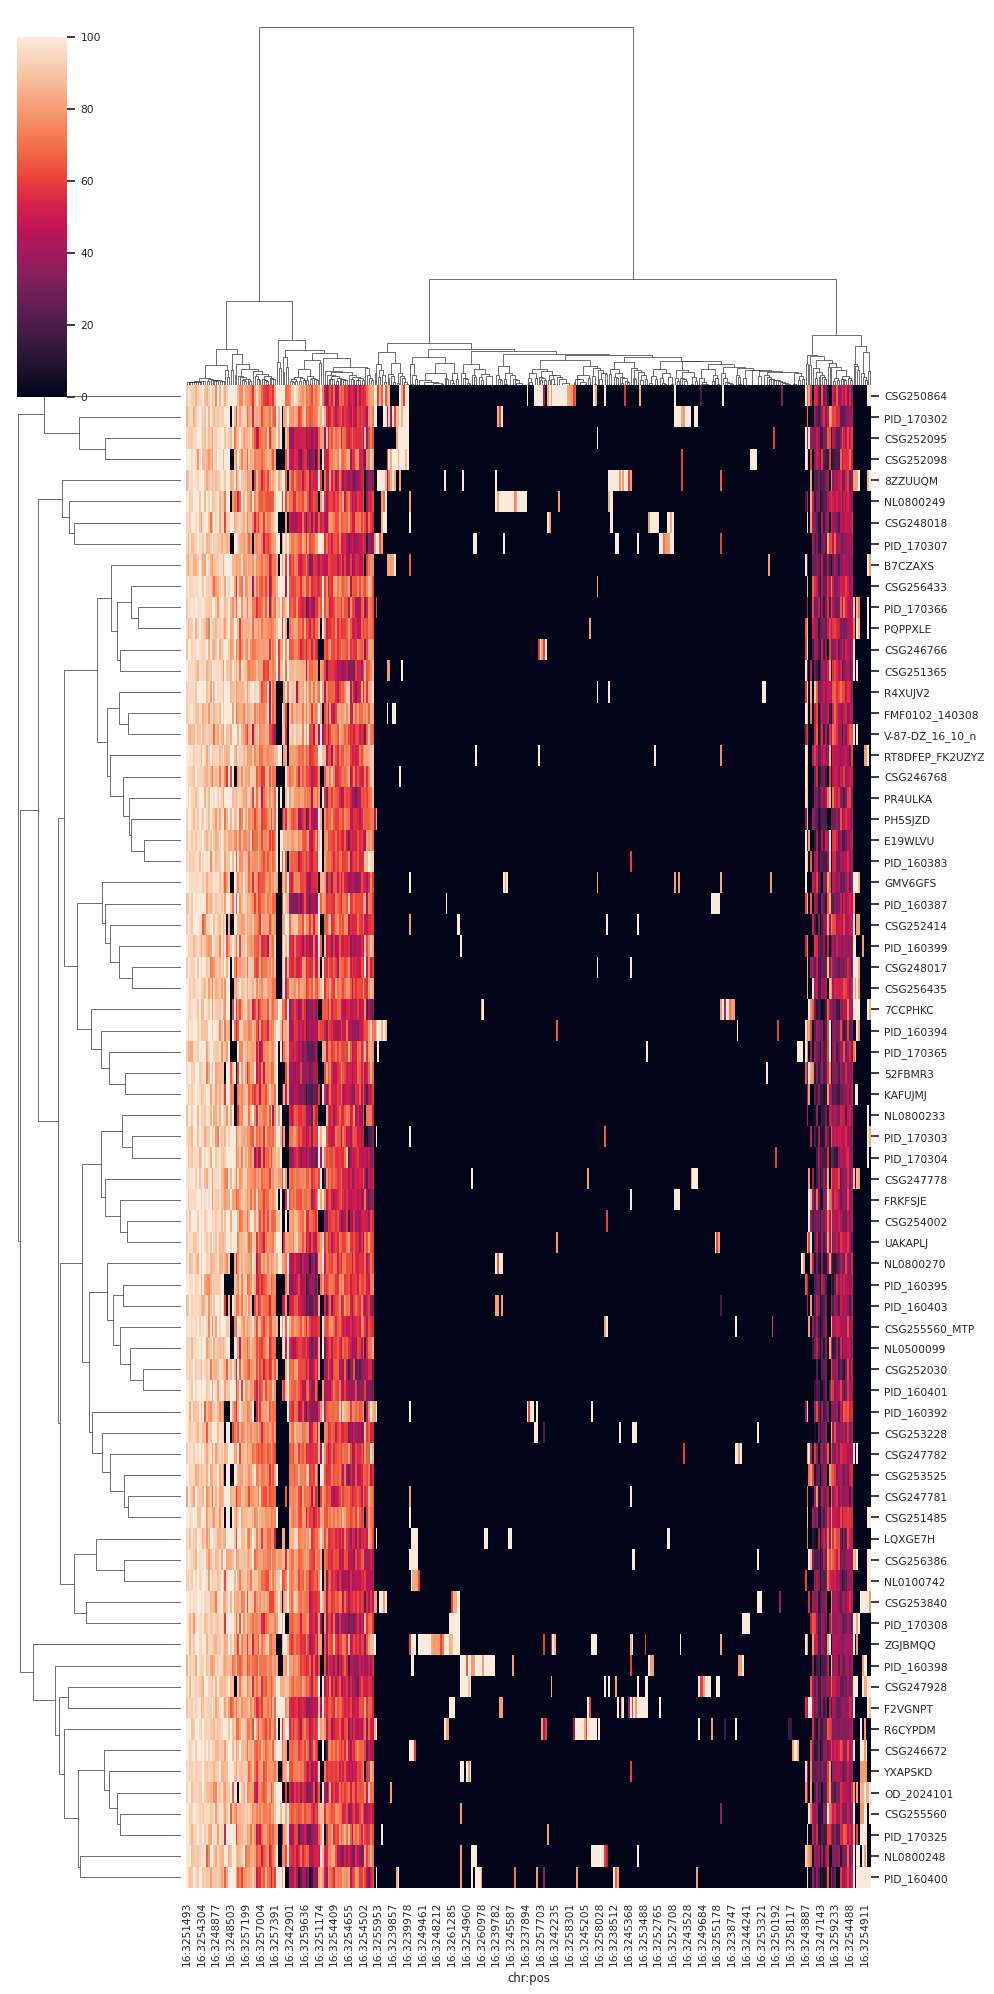

In [41]:
# Seaborn's clustermap does h-clust + visu:
sns.set(font_scale=0.7)
hclust = sns.clustermap(
    to_PCA,
    method='ward',
    figsize=(10, 20),
)
print(EPISIGN_OF_INTEREST)

In [42]:
# To stop exec of notebook
#assert False

## Heatmaps

In [43]:
# Simple one
# MEMO: Have to drop coord, otherwise does not plot correctly (too many rows probably)
print(EPISIGN_OF_INTEREST)
fig = px.imshow(
    to_PCA.T[EPISIGN_OF_INTEREST].T.reset_index(drop=True),
    text_auto=True
)
fig.update_layout(
    yaxis=dict(tickfont_size=7)
)

['PID_160383', 'NL0500099', 'CSG255560_MTP']


In [44]:
# MEMO: With index, plot broken with 'px.imshow'
names = to_PCA.index
coord = to_PCA.columns

print(to_PCA.info())

go.Figure(data=go.Heatmap(
    z = to_PCA.to_numpy(),
    x = coord,
    y = names
))

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 52FBMR3 to ZGJBMQQ
Columns: 372 entries, 16:3241981 to 16:3260416
dtypes: int64(372)
memory usage: 209.0+ KB
None


In [45]:
# MEMO: Have to drop index, otherwise plot broken
# Width/height empirical bellow
# Correct param is 'tickfont' (and not 'textfont')
fig = px.imshow(
    to_PCA.to_numpy(),
    y = names,
    x = coord,
    width = 15000,
    height = 1000
)
fig.update_layout(
    autosize=False,
    xaxis=dict(tickfont=dict(size=5)),
    yaxis=dict(tickfont=dict(size=5))
)

## PCA

In [46]:
# Run PCA:
NB_COMPON=2
pca = PCA(n_components=NB_COMPON)
pcs = pca.fit_transform(to_PCA.to_numpy())

print(f"Trustworthiness of the low-dimensional embedding for PCA: {trustworthiness(to_PCA, pcs, n_neighbors=2)}")

# Make a dict with '% variance explained' for each component:
dict_compon = {'compon'+str(i) : str(round(pca.explained_variance_ratio_[i]*100,4)) for i in range(NB_COMPON)}

Trustworthiness of the low-dimensional embedding for PCA: 0.6539384454877413


In [47]:
# Top N features of each componennt
compon_0_top = np.abs(pca.components_[0]).argsort()[::-1][:5]
print("Component 0:", list(X.index[compon_0_top]))

compon_1_top = np.abs(pca.components_[1]).argsort()[::-1][:5]
print("Component 1:", list(X.index[compon_1_top]))

Component 0: ['16:3254096', '16:3254102', '16:3254071', '16:3254053', '16:3254127']
Component 1: ['16:3256363', '16:3239920', '16:3255822', '16:3239978', '16:3239950']


In [48]:
# Put results into a dataframe
# WARN: bellow 'dict.keys' assume orderedDict
pcs_df = pd.DataFrame(
    pcs,
    index=X.columns,
    columns=dict_compon.keys()
)
print(pcs_df.loc[EPISIGN_OF_INTEREST])

                  compon0    compon1
PID_160383     -51.060037  36.050715
NL0500099     -102.967169 -28.408900
CSG255560_MTP  -32.193413 -11.443377


In [49]:
# Plot PCA
color_selected = [ x in EPISIGN_OF_INTEREST for x in pcs_df.index ]

x_compon = 'compon0'
y_compon = 'compon1'

fig = px.scatter(
        pcs_df,
        x=x_compon,
        y=y_compon,
        hover_data=[pcs_df.index],
        color=color_selected,
        labels={x_compon:':'.join([x_compon,"", dict_compon[x_compon]]), y_compon:':'.join([y_compon,"",dict_compon[y_compon]])}
)
fig.show()

## t-SNE

In [50]:
# Run t-SNE:
# MEMOs:
# - In Joris' paper they use 'preplex=2'
# - t-SNE is stochastic -> re-run multiple times ?
#
tsne = TSNE(n_components=2, perplexity=2).fit_transform(to_PCA)
print(f"Trustworthiness of the low-dimensional embedding for t-SNE: {trustworthiness(to_PCA, tsne, n_neighbors=2)}")

Trustworthiness of the low-dimensional embedding for t-SNE: 0.8057381324986959


In [51]:
# Put results into a dataframe
# WARN: bellow 'dict.keys' assume orderedDict
tsne_df = pd.DataFrame(
    tsne,
    index=X.columns,
    columns=('compon0', 'compon1')
)
subset_tsne = tsne_df.loc[EPISIGN_OF_INTEREST]
print(subset_tsne)

                 compon0    compon1
PID_160383     12.202820 -11.049893
NL0500099     -37.747707 -16.998316
CSG255560_MTP -39.915894 -19.749666


In [52]:
# Plot t-SNE
fig_tsne = plot_df(tsne_df, EPISIGN_OF_INTEREST)
fig_tsne.show()

### Add last row otherwise something show in above plot